# Session 6 — Descent and Exact Line Search

This notebook follows the Session 6 PCW workflow:

1. Visualize descent steps on a contour plot.
2. Restrict a multivariable function to a one-variable line-search function.
3. Find a local minimum of the line-search function with bisection.
4. Combine these ideas into an exact line-search algorithm.
5. Test the algorithm on the quadratic bowl $f(x,y)=x^2+y^2$.


## 1. Plotting descent steps

A descent iteration has the form

\[
x_{k+1}=x_k+\alpha_k d_k,
\]

where \(d_k\) is the chosen direction and \(\alpha_k\) is the step size.

Here we choose a two-variable function, an initial point \(x_0\), a fixed step size \(\alpha=0.5\), and two different unit direction vectors to obtain \(x_1\) and \(x_2\).


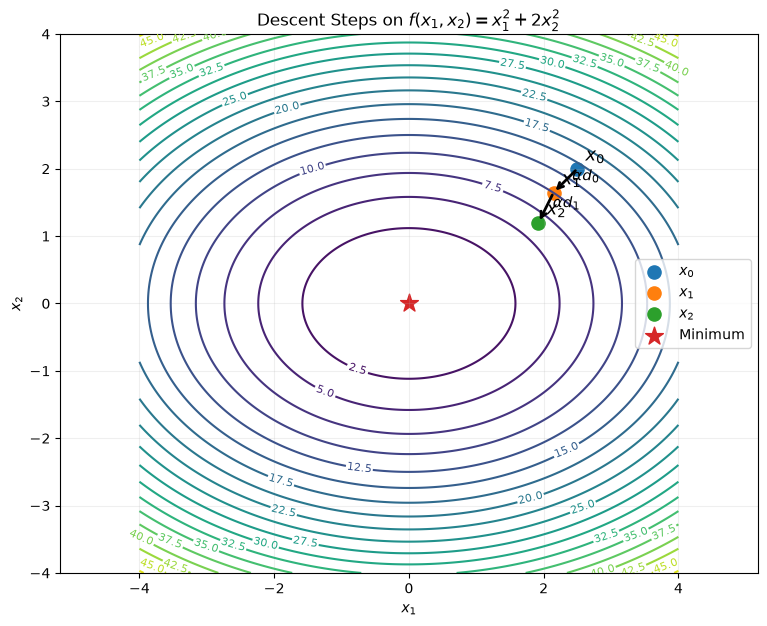

alpha = 0.5
d0 = [-0.70710678 -0.70710678]
d1 = [-0.4472136  -0.89442719]

x0 = [2.5 2. ]    f(x0) = 14.25
x1 = [2.14644661 1.64644661]    f(x1) = 10.02880592228744
x2 = [1.92283981 1.19923301]    f(x2) = 6.573632584579977


In [1]:
# Descent plot
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + 2*y**2

x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

x0 = np.array([2.5, 2.0])
alpha = 0.5

d0 = np.array([-1.0, -1.0])
d0 = d0 / np.linalg.norm(d0)
x1 = x0 + alpha * d0

d1 = np.array([-1.0, -2.0])
d1 = d1 / np.linalg.norm(d1)
x2 = x1 + alpha * d1

plt.figure(figsize=(9, 7))

contours = plt.contour(X, Y, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

plt.scatter(*x0, s=90, label=r"$x_0$")
plt.scatter(*x1, s=90, label=r"$x_1$")
plt.scatter(*x2, s=90, label=r"$x_2$")

plt.annotate("", xy=x1, xytext=x0, arrowprops=dict(arrowstyle="->", linewidth=2))
plt.annotate("", xy=x2, xytext=x1, arrowprops=dict(arrowstyle="->", linewidth=2))

plt.text(x0[0] + 0.12, x0[1] + 0.12, r"$x_0$", fontsize=13)
plt.text(x1[0] + 0.12, x1[1] + 0.12, r"$x_1$", fontsize=13)
plt.text(x2[0] + 0.12, x2[1] + 0.12, r"$x_2$", fontsize=13)

mid01 = (x0 + x1) / 2
mid12 = (x1 + x2) / 2
plt.text(mid01[0] + 0.1, mid01[1], r"$\alpha d_0$", fontsize=11)
plt.text(mid12[0] + 0.1, mid12[1], r"$\alpha d_1$", fontsize=11)

plt.scatter(0, 0, marker="*", s=180, label="Minimum")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title(r"Descent Steps on $f(x_1,x_2)=x_1^2+2x_2^2$")
plt.legend()
plt.grid(alpha=0.2)
plt.axis("equal")
plt.show()

print("alpha =", alpha)
print("d0 =", d0)
print("d1 =", d1)
print()
print("x0 =", x0, "   f(x0) =", f(*x0))
print("x1 =", x1, "   f(x1) =", f(*x1))
print("x2 =", x2, "   f(x2) =", f(*x2))


## 2. Line search

For the example

\[
f(x,y)=\sin(xy),
\qquad
x_i=
\begin{bmatrix}
1\\
1
\end{bmatrix},
\qquad
d_i=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\]

we have

\[
x_i+\alpha d_i=
\begin{bmatrix}
1+\alpha\\
1
\end{bmatrix}.
\]

Therefore,

\[
f(x_i+\alpha d_i)=\sin(1+\alpha).
\]

The first plot shows the original two-variable surface; the second shows the one-dimensional function encountered while moving along the chosen line.


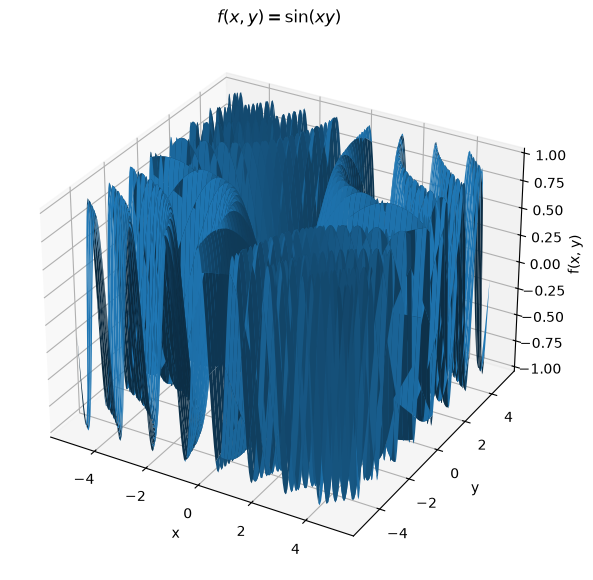

In [2]:
# 3D plot of f(x, y) = sin(xy)

x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)

X, Y = np.meshgrid(x, y)
Z = np.sin(X * Y)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title(r"$f(x,y)=\sin(xy)$")

plt.show()


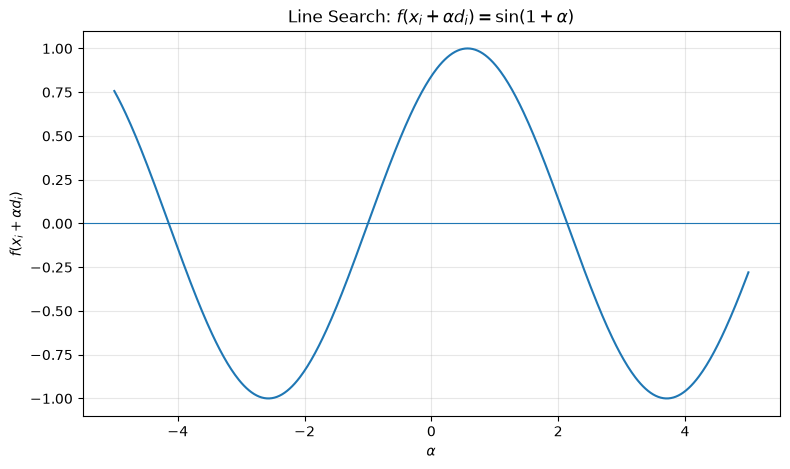

In [3]:
# Single-variable line-search function

alpha = np.linspace(-5, 5, 500)
line_search_f = np.sin(1 + alpha)

plt.figure(figsize=(9, 5))
plt.plot(alpha, line_search_f)
plt.axhline(0, linewidth=0.8)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$f(x_i + \alpha d_i)$")
plt.title(r"Line Search: $f(x_i+\alpha d_i)=\sin(1+\alpha)$")

plt.grid(alpha=0.3)
plt.show()


## 3. Finding the line-search minimum

The second plot is a one-dimensional slice of the first plot along the direction \(d_i=[1,0]^T\) starting from \(x_i=[1,1]^T\).

For

\[
g(\alpha)=\sin(1+\alpha),
\]

\[
g'(\alpha)=\cos(1+\alpha).
\]

The first positive local minimum occurs when

\[
1+\alpha=\frac{3\pi}{2},
\]

so

\[
\alpha^*=\frac{3\pi}{2}-1\approx 3.71239.
\]

We can also estimate this value numerically using bisection on the derivative. The interval \([0,5]\) contains both a maximum and a minimum, so for the derivative-sign version of bisection we use a bracket such as \([1,5]\).


In [4]:
# Bisection for the line-search minimum

f_line = lambda alpha: np.sin(1 + alpha)

def central_difference(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

fprime = lambda alpha: central_difference(f_line, alpha)

def bisection_min_counter(fprime, a, b, epsilon=0.001, no_iter=100):
    count = 0

    for _ in range(no_iter):
        m = (a + b) / 2
        fm = fprime(m)

        if abs(fm) < 1e-12:
            return m, m, count

        if fm > 0:
            b = m
        else:
            a = m

        count += 1

        if abs(b - a) < epsilon:
            return a, b, count

    raise RuntimeError("Number of iterations exhausted")

result = bisection_min_counter(fprime, 1, 5, 0.001, 100)
a, b, iterations = result
alpha_estimate = (a + b) / 2

print("Bisection interval:", result)
print("Estimated alpha:", alpha_estimate)
print("Exact alpha:", 3 * np.pi / 2 - 1)


Bisection interval: (3.7119140625, 3.712890625, 12)
Estimated alpha: 3.71240234375
Exact alpha: 3.7123889803846897


## 4. Exact line-search algorithm

The exact line-search workflow is:

1. Fix a design point \(x_i\) and direction \(d_i\).
2. Form the one-variable function \(\phi(\alpha)=f(x_i+\alpha d_i)\).
3. Find an interval that brackets a local minimum.
4. Apply a one-dimensional minimum-finding method.
5. Return the corresponding step size \(\alpha^*\) and next point \(x_{i+1}=x_i+\alpha^*d_i\).

We test the method on

\[
f(x,y)=x^2+y^2,
\quad
x_0=[1,1]^T,
\quad
d_0=-[1/\sqrt{2},1/\sqrt{2}]^T.
\]


In [5]:
# Exact line search

def central_difference(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)


def expand_interval(f, a=0.0, b=0.25, max_iter=100):
    if central_difference(f, a) >= 0:
        raise ValueError("The chosen direction is not a descent direction.")

    for _ in range(max_iter):
        if central_difference(f, b) > 0:
            return a, b

        b *= 2

    raise RuntimeError("Could not bracket a minimum.")


def bisection_minimum(f, a, b, epsilon=1e-8, max_iter=1000):
    if central_difference(f, a) >= 0 or central_difference(f, b) <= 0:
        raise ValueError("Need f'(a) < 0 and f'(b) > 0.")

    for _ in range(max_iter):
        m = (a + b) / 2
        dm = central_difference(f, m)

        if abs(dm) < 1e-10:
            return m

        if dm > 0:
            b = m
        else:
            a = m

        if abs(b - a) < epsilon:
            return (a + b) / 2

    raise RuntimeError("Maximum iterations reached.")


def exact_line_search(f, x_i, d_i, initial_interval=(0, 0.25)):
    phi = lambda alpha: f(x_i + alpha * d_i)

    a, b = expand_interval(
        phi,
        initial_interval[0],
        initial_interval[1]
    )

    alpha_star = bisection_minimum(phi, a, b)
    x_next = x_i + alpha_star * d_i

    return alpha_star, x_next


f_bowl = lambda x: x[0]**2 + x[1]**2

x0 = np.array([1.0, 1.0])
d0 = -np.array([
    1 / np.sqrt(2),
    1 / np.sqrt(2)
])

alpha_star, x1 = exact_line_search(f_bowl, x0, d0)

print("x0 =", x0)
print("direction =", d0)
print("optimal alpha =", alpha_star)
print("x1 =", x1)
print("f(x0) =", f_bowl(x0))
print("f(x1) =", f_bowl(x1))


x0 = [1. 1.]
direction = [-0.70710678 -0.70710678]
optimal alpha = 1.414213564246893
x1 = [-1.32497502e-09 -1.32497502e-09]
f(x0) = 2.0
f(x1) = 3.511117599778507e-18


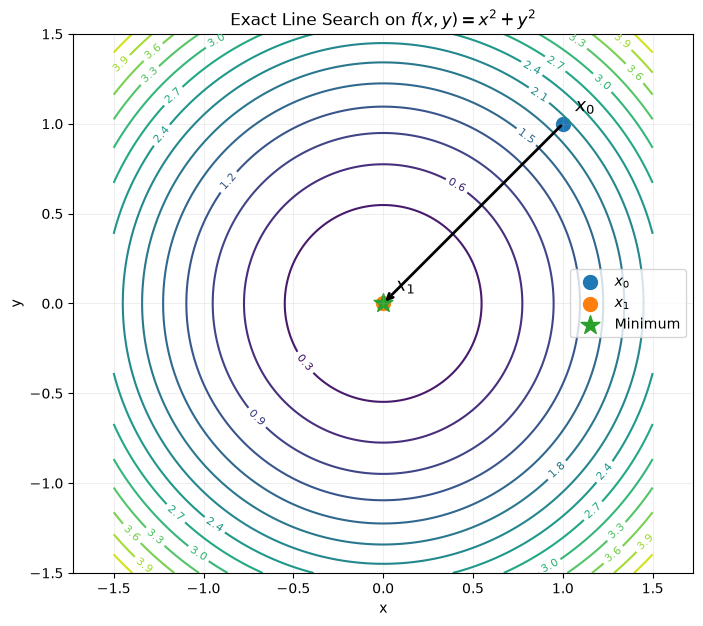

In [6]:
# Contour plot showing exact line-search descent on the quadratic bowl

x = np.linspace(-1.5, 1.5, 300)
y = np.linspace(-1.5, 1.5, 300)

X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(8, 7))

contours = plt.contour(X, Y, Z, levels=15)
plt.clabel(contours, fontsize=8)

plt.scatter(*x0, s=100, label=r"$x_0$")
plt.scatter(*x1, s=100, label=r"$x_1$")
plt.scatter(0, 0, marker="*", s=200, label="Minimum")

plt.annotate(
    "",
    xy=x1,
    xytext=x0,
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

plt.text(x0[0] + 0.07, x0[1] + 0.07, r"$x_0$", fontsize=13)
plt.text(x1[0] + 0.07, x1[1] + 0.07, r"$x_1$", fontsize=13)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Exact Line Search on $f(x,y)=x^2+y^2$")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()


## 5. Result

For the quadratic bowl,

\[
x_0=
\begin{bmatrix}
1\\
1
\end{bmatrix},
\qquad
d_0=
-
\begin{bmatrix}
1/\sqrt{2}\\
1/\sqrt{2}
\end{bmatrix}.
\]

Because \(d_0\) is a unit vector pointing directly toward the minimum at the origin, exact line search finds

\[
\alpha^*=\sqrt{2}\approx 1.4142.
\]

Then

\[
x_1=x_0+\alpha^*d_0\approx
\begin{bmatrix}
0\\
0
\end{bmatrix}.
\]

So this example does **not** need any additional descent steps: the minimum is reached in one exact line-search step.
